# Train/Test Sequential CNN on EMNIST digits

In [ ]:
!unzip -q emnist_digits_png.zip -d /content/

--- Loading EMNIST Digits from local PNG folders ---
Found 240000 files belonging to 10 classes.
Using 192000 files for training.
Found 240000 files belonging to 10 classes.
Using 48000 files for validation.
Found 40000 files belonging to 10 classes.
Class names: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Epoch 1/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step - accuracy: 0.9661 - loss: 0.1178
Epoch 1: val_accuracy improved from -inf to 0.99098, saving model to emnist_best_model.keras
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 504s 312ms/step - accuracy: 0.9661 - loss: 0.1178 - val_accuracy: 0.9910 - val_loss: 0.0317 - learning_rate: 0.0010
Epoch 2/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 0.9931 - loss: 0.0239
Epoch 2: val_accuracy improved from 0.99098 to 0.99244, saving model to emnist_best_model.keras
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 529s 315ms/step - accuracy: 0.9931 - loss: 0.0239 - val_accuracy: 0.9924 - val_loss: 0.0250 - learning_rate: 0.0010
Epoch 3/50
1500/1500 ━

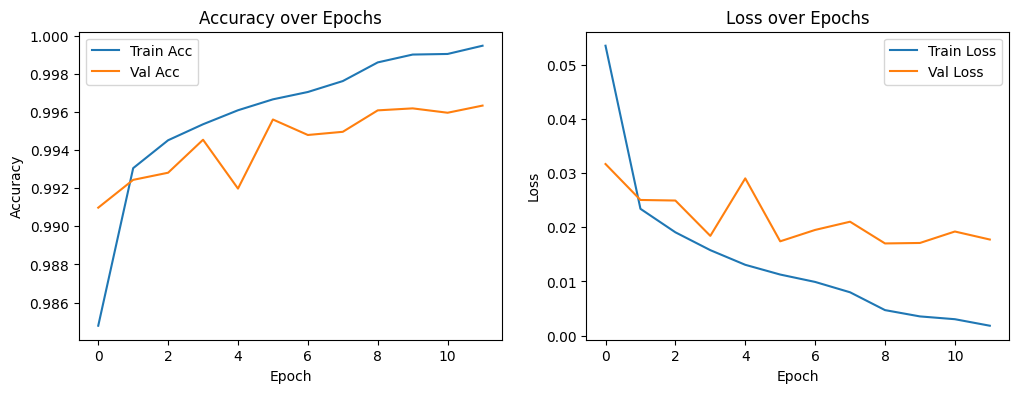

Generating predictions (this may take a moment on CPU)...

--- Test Set Confusion Matrix ---


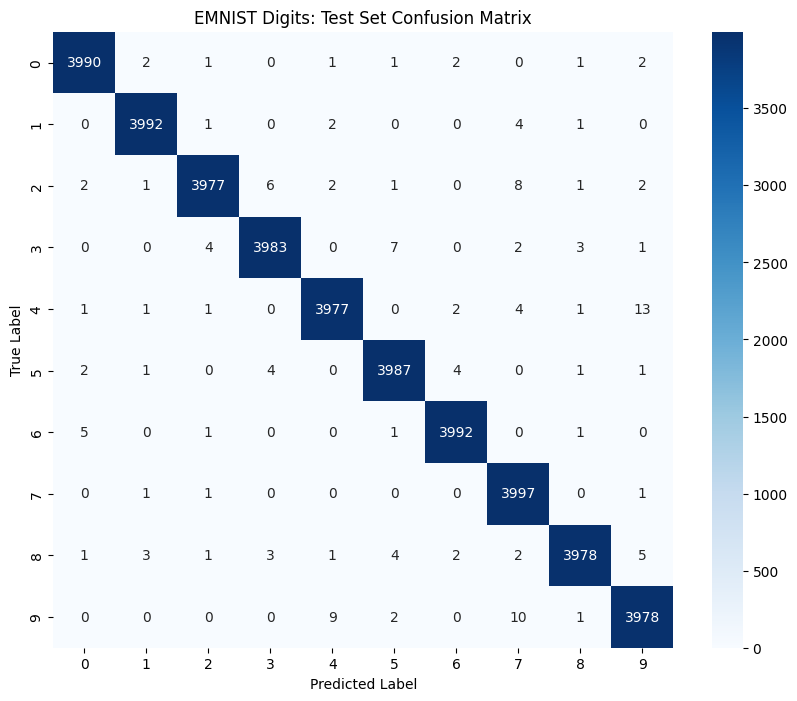


--- Test Set Classification Report ---
              precision    recall  f1-score   support

           0     0.9973    0.9975    0.9974      4000
           1     0.9978    0.9980    0.9979      4000
           2     0.9975    0.9942    0.9959      4000
           3     0.9967    0.9958    0.9962      4000
           4     0.9962    0.9942    0.9952      4000
           5     0.9960    0.9968    0.9964      4000
           6     0.9975    0.9980    0.9978      4000
           7     0.9926    0.9992    0.9959      4000
           8     0.9975    0.9945    0.9960      4000
           9     0.9938    0.9945    0.9941      4000

    accuracy                         0.9963     40000
   macro avg     0.9963    0.9963    0.9963     40000
weighted avg     0.9963    0.9963    0.9963     40000



In [ ]:
!unzip -q emnist_digits_png.zip -d /content/

"""
1. No Layer/ Dataset level Augmentation
2. BatchNormalization added before RELU
Cov2D-->BatchNormalization--->RELU
"""

import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow import keras
from keras import layers, models, callbacks
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report


def get_keras_dataset():
    print("--- Loading EMNIST Digits from local PNG folders ---")

    DATA_DIR = "/content"
    IMG_SIZE = (28, 28)
    BATCH_SIZE = 128
    SEED = 42

    # ---------------------------------------------------------
    # 1. Load TRAIN dataset (folder-based)
    # ---------------------------------------------------------
    train_ds = tf.keras.utils.image_dataset_from_directory(
        f"{DATA_DIR}/train",
        validation_split=0.2,
        subset="training",
        seed=SEED,
        color_mode="grayscale",
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE
    )

    val_ds = tf.keras.utils.image_dataset_from_directory(
        f"{DATA_DIR}/train",
        validation_split=0.2,
        subset="validation",
        seed=SEED,
        color_mode="grayscale",
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE
    )
    # ---------------------------------------------------------
    # 2. Load TEST dataset
    # ---------------------------------------------------------
    test_ds = tf.keras.utils.image_dataset_from_directory(
        directory=f"{DATA_DIR}/test",
        labels="inferred",
        label_mode="int",
        color_mode="grayscale",
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    class_names = train_ds.class_names
    print("Class names:", class_names)

    # ---------------------------------------------------------
    # 4. Normalization layer (NO augmentation)
    # ---------------------------------------------------------
    norm_layer = layers.Normalization(axis=None)

    norm_layer.adapt(
        train_ds
        .map(lambda x, y: tf.cast(x, tf.float32) / 255.0)
        .take(500)   # enough samples for statistics
    )

    preprocessing_model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Rescaling(1./255),
        norm_layer
    ], name="preprocessing_head")

    # ---------------------------------------------------------
    # 5. Final pipeline
    # ---------------------------------------------------------
    def finalize(ds, shuffle=False):
        if shuffle:
            ds = ds.shuffle(10000, seed=SEED)
        return ds.prefetch(tf.data.AUTOTUNE)

    train_ds = finalize(train_ds, shuffle=True)
    val_ds = finalize(val_ds)
    test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

    return train_ds, val_ds, test_ds, preprocessing_model


def build_cnn(preprocessing_layer):
    model = models.Sequential([
        preprocessing_layer,

        # Block 1
        layers.Conv2D(32, (3, 3), padding='same', kernel_initializer='he_normal'),
        layers.Activation('relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Block 2
        layers.Conv2D(64, (3, 3), padding='same', kernel_initializer='he_normal'),
        layers.Activation('relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Block 3
        layers.Conv2D(128, (3, 3), padding='same', kernel_initializer='he_normal'),
        layers.Activation('relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)), # Added pooling here to reduce Flatten size

        layers.Flatten(),
        layers.Dense(256, kernel_initializer='he_normal'), # Increased to 256
        layers.Activation('relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.4), # Increased dropout because we increased capacity
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


if __name__ == "__main__":
    train_data, val_data, test_data, prep_layer = get_keras_dataset()
    model = build_cnn(prep_layer)
    model.summary()

    # Callbacks
    early_stop = callbacks.EarlyStopping(
        monitor='val_loss', patience=3, restore_best_weights=True, verbose=1
    )

    reduce_lr = callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1
    )

    checkpoint = callbacks.ModelCheckpoint(
    "emnist_best_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
    )

    # Train (Removed batch_size and validation_split because data is already handled)
    history = model.fit(
        train_data,
        epochs=50,
        validation_data=val_data,
        callbacks=[early_stop, reduce_lr, checkpoint],
        verbose=1
    )

    test_loss, test_acc = model.evaluate(test_data, verbose=2)
    print(f"\nTest accuracy: {test_acc:.4f}")

    # ===============================================================
    #  STEP 8: Plot Accuracy & Loss
    # ===============================================================
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    # ===============================================================
    # STEP 11: Confusion Matrix & Classification Report
    # ===============================================================

    def get_actual_and_predicted(dataset):
        """ Helper function to extract labels from a tf.data.Dataset """
        y_true = []
        y_pred = []
        print("Generating predictions (this may take a moment on CPU)...")
        for images, labels in dataset:
            preds = model.predict(images, verbose=0)
            y_pred.extend(np.argmax(preds, axis=1))
            y_true.extend(labels.numpy())
        return np.array(y_true), np.array(y_pred)

    # 1️⃣ Extract true labels and predictions
    # Note: Use test_data (and train_data if you have time on CPU)
    y_test_true, y_test_pred = get_actual_and_predicted(test_data)

    # 2️⃣ Compute confusion matrix
    cm_test = confusion_matrix(y_test_true, y_test_pred)

    # 3️⃣ Plot function for better visualization
    def plot_confusion_matrix(cm, title='Confusion Matrix'):
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.title(title)
        plt.show()

    print("\n--- Test Set Confusion Matrix ---")
    plot_confusion_matrix(cm_test, title='EMNIST Digits: Test Set Confusion Matrix')

    # 4️⃣ Classification report
    print("\n--- Test Set Classification Report ---")
    # EMNIST Digits has 10 classes: 0-9
    target_names = [str(i) for i in range(10)]
    print(classification_report(y_test_true, y_test_pred, target_names=target_names, digits=4))

# Fine Pre-trained Sequential CNN on Fonts-Based digits

## Pro Tips for Phase 1 Fine-Tuning
### Tip A: The BN "Freeze" Debate
In my corrected code above, I only froze Conv2D layers.

The Reason: Batch Normalization (BN) layers keep track of the mean and variance of your data. EMNIST (handwritten) and Synthetic Fonts have very different pixel distributions. If you freeze BN layers, you force the model to use "handwritten" statistics on "crisp" fonts, which often leads to lower accuracy.

Action: Let BN layers remain trainable=True. This allows the model to "re-center" its understanding of what a "digit" looks like in the new font domain.

### Tip B: Data Prefetching (Performance)
Your training will be significantly faster if you use the tf.data pipeline's prefetching. Add this right before you return from get_keras_dataset:

`AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)`

### Tip C: Dense Layer Check
Since you have 6,000+ images per class but only train:test = 631 : 496 styles, your model is not at risk of "Style Memorization."

If you see Train Accuracy: 99% but Val Accuracy: 85%, your Dense(256) layer is too large or needs more dropout.

In Phase 1, if the gap is wide, increase layers.Dropout(0.4) to 0.5.

### Tip D: Faster Metrics
Instead of the manual loop in get_actual_and_predicted, use:

`y_test_true = np.concatenate([y for x, y in test_data], axis=0)
y_test_pred = np.argmax(model.predict(test_data), axis=1)`

Note: This only works if shuffle=False in your test dataset (which you correctly set).

## Summary of Data Domain
Because Google Fonts are mathematically perfect, the model might find it too easy to reach 100% training accuracy. The real test is your "unseen" font test set. If accuracy drops there, Phase 2 (GAP layer) will be your best friend.

--- Loading EMNIST Digits from local PNG folders ---
Found 62190 files belonging to 10 classes.
Using 49752 files for training.
Found 62190 files belonging to 10 classes.
Using 12438 files for validation.
Found 44730 files belonging to 10 classes.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ preprocessing_head (Sequential) │ (None, 28, 28, 1)      │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 392,333 (1.50 MB)

 Trainable params: 298,698 (1.14 MB)

 Non-trainable params: 93,635 (365.77 KB)

Epoch 1/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.8653 - loss: 0.6681
Epoch 1: val_accuracy improved from -inf to 0.95787, saving model to fine_tune_best_model.keras
389/389 ━━━━━━━━━━━━━━━━━━━━ 95s 220ms/step - accuracy: 0.8654 - loss: 0.6675 - val_accuracy: 0.9579 - val_loss: 0.1412 - learning_rate: 1.0000e-04
Epoch 2/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.9534 - loss: 0.1606
Epoch 2: val_accuracy improved from 0.95787 to 0.98175, saving model to fine_tune_best_model.keras
389/389 ━━━━━━━━━━━━━━━━━━━━ 86s 221ms/step - accuracy: 0.9534 - loss: 0.1606 - val_accuracy: 0.9817 - val_loss: 0.0637 - learning_rate: 1.0000e-04
Epoch 3/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.9712 - loss: 0.0961
Epoch 3: val_accuracy improved from 0.98175 to 0.98802, saving model to fine_tune_best_model.keras
389/389 ━━━━━━━━━━━━━━━━━━━━ 85s 219ms/step - accuracy: 0.9712 - loss: 0.0961 - val_accuracy: 0.9880 - val_loss: 0.0435 - learning_rate: 1.0000e-0

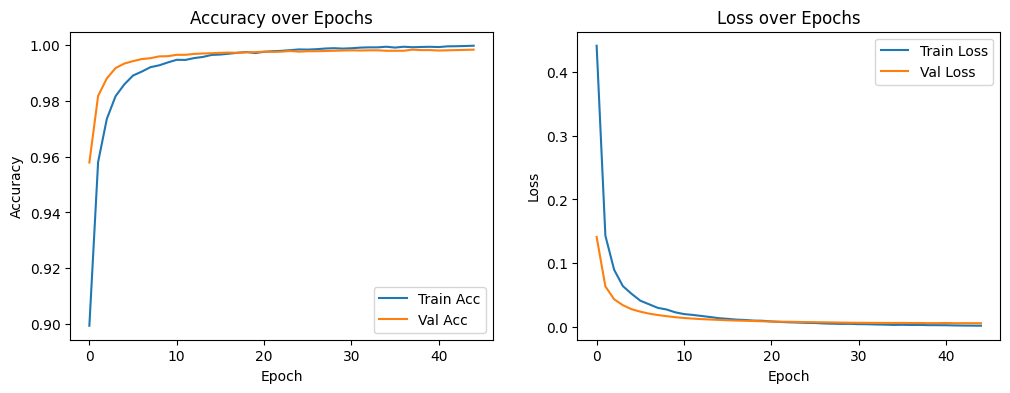

Generating predictions (this may take a moment on CPU)...

--- Test Set Confusion Matrix ---


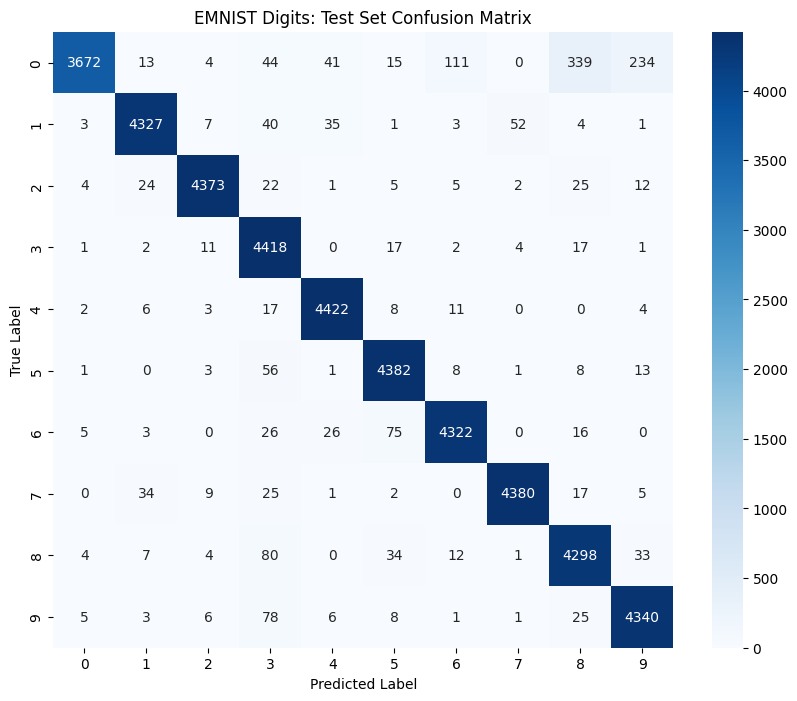


--- Test Set Classification Report ---
              precision    recall  f1-score   support

           0     0.9932    0.8209    0.8989      4473
           1     0.9792    0.9674    0.9732      4473
           2     0.9894    0.9776    0.9835      4473
           3     0.9193    0.9877    0.9523      4473
           4     0.9755    0.9886    0.9820      4473
           5     0.9637    0.9797    0.9716      4473
           6     0.9658    0.9662    0.9660      4473
           7     0.9863    0.9792    0.9827      4473
           8     0.9050    0.9609    0.9321      4473
           9     0.9347    0.9703    0.9522      4473

    accuracy                         0.9598     44730
   macro avg     0.9612    0.9598    0.9595     44730
weighted avg     0.9612    0.9598    0.9595     44730



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras import callbacks
import tensorflow as tf
from tensorflow.keras import models, layers

# Unzip the train/test dataset in /content
!unzip -q train_synthetic_digits_dataset.zip -d /content/train
!unzip -q test_synthetic_digits_dataset.zip -d /content/test

def get_keras_dataset():
    print("--- Loading EMNIST Digits from local PNG folders ---")

    TRAIN_DATA_DIR = "/content/train/content/synthetic_digits_dataset"
    TEST_DATA_DIR = "/content/test/content/synthetic_digits_dataset"
    IMG_SIZE = (28, 28)
    BATCH_SIZE = 128
    SEED = 42

    # ---------------------------------------------------------
    # 1. Load TRAIN dataset (folder-based)
    # ---------------------------------------------------------
    train_ds = tf.keras.utils.image_dataset_from_directory(
        directory=TRAIN_DATA_DIR,
        validation_split=0.2,
        subset="training",
        seed=SEED,
        color_mode="grayscale",
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE
    )

    val_ds = tf.keras.utils.image_dataset_from_directory(
        directory=TRAIN_DATA_DIR,
        validation_split=0.2,
        subset="validation",
        seed=SEED,
        color_mode="grayscale",
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE
    )
    # ---------------------------------------------------------
    # 2. Load TEST dataset
    # ---------------------------------------------------------
    test_ds = tf.keras.utils.image_dataset_from_directory(
        directory=TEST_DATA_DIR,
        labels="inferred",
        label_mode="int",
        color_mode="grayscale",
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    AUTOTUNE = tf.data.AUTOTUNE
    train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
    val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
    test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

    return train_ds, val_ds, test_ds


def freeze_all_blocks():

  # 1. Load your trained EMNIST model
  model = models.load_model('emnist_best_model.keras')

  for layer in model.layers:
      # Professional Tip: Only freeze weights, let BN layers adapt
      if isinstance(layer, layers.Conv2D) and not layer.name.startswith('dense'):
          layer.trainable = False

  model.compile(
      optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
      loss='sparse_categorical_crossentropy',
      metrics=['accuracy']
  )

  return model

if __name__ == "__main__":
    train_data, val_data, test_data = get_keras_dataset()
    model = freeze_all_blocks()
    model.summary()

    # Callbacks
    early_stop = callbacks.EarlyStopping(
        monitor='val_loss', patience=3, restore_best_weights=True, verbose=1
    )

    reduce_lr = callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1
    )

    checkpoint = callbacks.ModelCheckpoint(
    "fine_tune_best_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
    )

    # Train (Removed batch_size and validation_split because data is already handled)
    history = model.fit(
        train_data,
        epochs=50,
        validation_data=val_data,
        callbacks=[early_stop, reduce_lr, checkpoint],
        verbose=1
    )

    test_loss, test_acc = model.evaluate(test_data, verbose=2)
    print(f"\nTest accuracy: {test_acc:.4f}")

    # ===============================================================
    #  STEP 8: Plot Accuracy & Loss
    # ===============================================================
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    # ===============================================================
    # STEP 11: Confusion Matrix & Classification Report
    # ===============================================================

    def get_actual_and_predicted(dataset):
        """ Helper function to extract labels from a tf.data.Dataset """
        y_true = []
        y_pred = []
        print("Generating predictions (this may take a moment on CPU)...")
        for images, labels in dataset:
            preds = model.predict(images, verbose=0)
            y_pred.extend(np.argmax(preds, axis=1))
            y_true.extend(labels.numpy())
        return np.array(y_true), np.array(y_pred)

    # 1️⃣ Extract true labels and predictions
    # Note: Use test_data (and train_data if you have time on CPU)
    y_test_true, y_test_pred = get_actual_and_predicted(test_data)

    # 2️⃣ Compute confusion matrix
    cm_test = confusion_matrix(y_test_true, y_test_pred)

    # 3️⃣ Plot function for better visualization
    def plot_confusion_matrix(cm, title='Confusion Matrix'):
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.title(title)
        plt.show()

    print("\n--- Test Set Confusion Matrix ---")
    plot_confusion_matrix(cm_test, title='EMNIST Digits: Test Set Confusion Matrix')

    # 4️⃣ Classification report
    print("\n--- Test Set Classification Report ---")
    # EMNIST Digits has 10 classes: 0-9
    target_names = [str(i) for i in range(10)]
    print(classification_report(y_test_true, y_test_pred, target_names=target_names, digits=4))



In [ ]:
from google.colab import files

files.download("fine_tune_best_model.keras")

model = freeze_all_blocks()
print(f"{'Layer Name':<30} | {'Trainable':<10}")
print("-" * 45)
for layer in model.layers:
    print(f"{layer.name:<30} | {str(layer.trainable):<10}")